# Install R

In [1]:
%load_ext rpy2.ipython


# Connect to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


# Combine the FPCA and Covariates

In [3]:
%%R

library(dplyr)

cat("Reading Post_4_Covariates table...\n\n")

post_4_covariates <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_4_Covariates.csv"
)

cat("Post_4_Covariates dimensions:\n")
print(dim(post_4_covariates))

cat("\nFirst 5 rows:\n")
print(as.data.frame(head(post_4_covariates, 5)))

# ------------------------------------------------

cat("\n\nReading Post_3_Top3_FPCA_Scores table...\n\n")

top3_scores <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_3_Top3_FPCA_Scores.csv"
)

cat("Post_3_Top3_FPCA_Scores dimensions:\n")
print(dim(top3_scores))

cat("\nColumn names:\n")
print(names(top3_scores))

cat("\nFirst 5 rows:\n")
print(as.data.frame(head(top3_scores, 5)))

Reading Post_4_Covariates table...

Post_4_Covariates dimensions:
[1] 4625   20

First 5 rows:
   SEQN     cycle age  bmi  sex     race_ethnicity         education
1 62174 2011-2012  80 33.9 Male Non-Hispanic White College graduate+
2 62177 2011-2012  51 20.1 Male Non-Hispanic Asian   High school/GED
3 62178 2011-2012  80 28.5 Male Non-Hispanic White   High school/GED
4 62179 2011-2012  55 27.6 Male Non-Hispanic Asian College graduate+
5 62191 2011-2012  70   NA Male Non-Hispanic Black   High school/GED
  marital_status smoking_status alcohol_use hypertension diabetes heart_attack
1        Married          Never         Yes          Yes       No           No
2        Married        Current        <NA>           No       No           No
3        Widowed          Never          No           No       No           No
4        Married          Never          No           No       No           No
5       Divorced         Former         Yes           No       No           No
  stroke cancer s


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [4]:
%%R

library(dplyr)

cat("Reading Post_4_Covariates table...\n\n")

post_4_covariates <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_4_Covariates.csv"
)

cat("Post_4_Covariates dimensions:\n")
print(dim(post_4_covariates))

cat("\nFirst 5 rows:\n")
print(as.data.frame(head(post_4_covariates, 5)))

# ------------------------------------------------

cat("\n\nReading Post_3_Top3_FPCA_Scores table...\n\n")

top3_scores <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_3_FPCA_Scores.csv"
)

cat("Post_3_Top3_FPCA_Scores dimensions:\n")
print(dim(top3_scores))

cat("\nColumn names:\n")
print(names(top3_scores))

cat("\nFirst 5 rows:\n")
print(as.data.frame(head(top3_scores, 5)))

# ------------------------------------------------
# Check join key
# ------------------------------------------------

cat("\n\nChecking join key SEQN...\n")

cat("SEQN in post_4_covariates:", "SEQN" %in% names(post_4_covariates), "\n")
cat("SEQN in top3_scores:", "SEQN" %in% names(top3_scores), "\n")

if (!("SEQN" %in% names(post_4_covariates))) {
  stop("SEQN is missing from post_4_covariates")
}

if (!("SEQN" %in% names(top3_scores))) {
  stop("SEQN is missing from top3_scores")
}

# ------------------------------------------------
# Duplicate checks
# ------------------------------------------------

cat("\nDuplicate SEQN in post_4_covariates:\n")

dup_covariates <- post_4_covariates %>%
  count(SEQN) %>%
  filter(n > 1)

print(as.data.frame(dup_covariates))

cat("\nNumber of duplicated SEQN in covariates:\n")
print(nrow(dup_covariates))

cat("\nDuplicate SEQN in top3_scores:\n")

dup_scores <- top3_scores %>%
  count(SEQN) %>%
  filter(n > 1)

print(as.data.frame(dup_scores))

cat("\nNumber of duplicated SEQN in scores:\n")
print(nrow(dup_scores))

# ------------------------------------------------
# Missing patient checks
# ------------------------------------------------

cat("\n\nChecking patients missing from each side...\n")

missing_from_scores <- post_4_covariates %>%
  anti_join(top3_scores, by = "SEQN")

missing_from_covariates <- top3_scores %>%
  anti_join(post_4_covariates, by = "SEQN")

cat("\nPatients in covariates but missing FPCA scores:\n")
print(nrow(missing_from_scores))

cat("\nFirst 10 missing from scores:\n")
print(as.data.frame(head(missing_from_scores, 10)))

cat("\nPatients in FPCA scores but missing covariates:\n")
print(nrow(missing_from_covariates))

cat("\nFirst 10 missing from covariates:\n")
print(as.data.frame(head(missing_from_covariates, 10)))

# ------------------------------------------------
# Join tables
# ------------------------------------------------

cat("\n\nJoining tables by SEQN...\n")

post_5_covariates_fpca <- post_4_covariates %>%
  inner_join(
    top3_scores,
    by = "SEQN"
  )

cat("\nJoined table dimensions:\n")
print(dim(post_5_covariates_fpca))

cat("\nJoined table column names:\n")
print(names(post_5_covariates_fpca))

cat("\nFirst 10 rows of joined table:\n")
print(as.data.frame(head(post_5_covariates_fpca, 10)))

# ------------------------------------------------
# Post-join checks
# ------------------------------------------------

cat("\n\nPost-join checks...\n")

cat("\nRows in post_4_covariates:\n")
print(nrow(post_4_covariates))

cat("\nRows in top3_scores:\n")
print(nrow(top3_scores))

cat("\nRows in joined table:\n")
print(nrow(post_5_covariates_fpca))

cat("\nUnique SEQN in post_4_covariates:\n")
print(n_distinct(post_4_covariates$SEQN))

cat("\nUnique SEQN in top3_scores:\n")
print(n_distinct(top3_scores$SEQN))

cat("\nUnique SEQN in joined table:\n")
print(n_distinct(post_5_covariates_fpca$SEQN))

# ------------------------------------------------
# Missingness checks after join
# ------------------------------------------------

cat("\nMissing values by column in joined table:\n")

missing_by_column <- data.frame(
  variable = names(post_5_covariates_fpca),
  missing_n = sapply(
    post_5_covariates_fpca,
    function(x) sum(is.na(x))
  ),
  missing_percent = round(
    100 * sapply(
      post_5_covariates_fpca,
      function(x) sum(is.na(x))
    ) / nrow(post_5_covariates_fpca),
    1
  )
)

print(as.data.frame(missing_by_column))

# ------------------------------------------------
# Final pass/fail checks
# ------------------------------------------------

cat("\n\nFinal checks:\n")

if (nrow(missing_from_scores) == 0) {
  cat("PASS: Every covariate patient has FPCA scores.\n")
} else {
  cat("FAIL: Some covariate patients are missing FPCA scores.\n")
}

if (nrow(missing_from_covariates) == 0) {
  cat("PASS: Every FPCA patient has covariates.\n")
} else {
  cat("FAIL: Some FPCA patients are missing covariates.\n")
}

if (nrow(post_5_covariates_fpca) == n_distinct(post_5_covariates_fpca$SEQN)) {
  cat("PASS: One row per patient after join.\n")
} else {
  cat("FAIL: Duplicate patients exist after join.\n")
}

Reading Post_4_Covariates table...

Post_4_Covariates dimensions:
[1] 4625   20

First 5 rows:
   SEQN     cycle age  bmi  sex     race_ethnicity         education
1 62174 2011-2012  80 33.9 Male Non-Hispanic White College graduate+
2 62177 2011-2012  51 20.1 Male Non-Hispanic Asian   High school/GED
3 62178 2011-2012  80 28.5 Male Non-Hispanic White   High school/GED
4 62179 2011-2012  55 27.6 Male Non-Hispanic Asian College graduate+
5 62191 2011-2012  70   NA Male Non-Hispanic Black   High school/GED
  marital_status smoking_status alcohol_use hypertension diabetes heart_attack
1        Married          Never         Yes          Yes       No           No
2        Married        Current        <NA>           No       No           No
3        Widowed          Never          No           No       No           No
4        Married          Never          No           No       No           No
5       Divorced         Former         Yes           No       No           No
  stroke cancer s

In [5]:
%%R

library(dplyr)

# inner join by SEQN
post_5_covariates_fpca <- post_4_covariates %>%
  inner_join(
    top3_scores,
    by = "SEQN"
  )

cat("Joined table dimensions:\n")
print(dim(post_5_covariates_fpca))

cat("\nFirst 10 rows:\n")
print(as.data.frame(head(post_5_covariates_fpca, 10)))

Joined table dimensions:
[1] 4625   23

First 10 rows:
    SEQN     cycle age  bmi    sex     race_ethnicity         education
1  62174 2011-2012  80 33.9   Male Non-Hispanic White College graduate+
2  62177 2011-2012  51 20.1   Male Non-Hispanic Asian   High school/GED
3  62178 2011-2012  80 28.5   Male Non-Hispanic White   High school/GED
4  62179 2011-2012  55 27.6   Male Non-Hispanic Asian College graduate+
5  62191 2011-2012  70   NA   Male Non-Hispanic Black   High school/GED
6  62199 2011-2012  57 28.0   Male Non-Hispanic White College graduate+
7  62209 2011-2012  62 26.0 Female   Mexican American        <9th grade
8  62215 2011-2012  65 26.7 Female Non-Hispanic White   Some college/AA
9  62217 2011-2012  77 30.6 Female   Mexican American        <9th grade
10 62223 2011-2012  54 20.5   Male Non-Hispanic Asian   High school/GED
        marital_status smoking_status alcohol_use hypertension diabetes
1              Married          Never         Yes          Yes       No
2        

# Kaplan Meier Curve

Creating Kaplan-Meier curve...

Columns in dataset:
 [1] "SEQN"               "cycle"              "age"               
 [4] "bmi"                "sex"                "race_ethnicity"    
 [7] "education"          "marital_status"     "smoking_status"    
[10] "alcohol_use"        "hypertension"       "diabetes"          
[13] "heart_attack"       "stroke"             "cancer"            
[16] "self_rated_health"  "mortality_eligible" "death"             
[19] "followup_months"    "followup_years"     "FPCA_score_1"      
[22] "FPCA_score_2"       "FPCA_score_3"      

Death counts:

   0    1 
3824  801 

Follow-up summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   67.00   79.00   77.21   93.00  111.00 

KM fit summary:
Call: survfit(formula = Surv(followup_months, death) ~ 1, data = post_5_covariates_fpca)

 time n.risk n.event survival  std.err lower 95% CI upper 95% CI
    0   4625       1    1.000 0.000216        0.999        1.000
    1   4624       2    0.999 0.

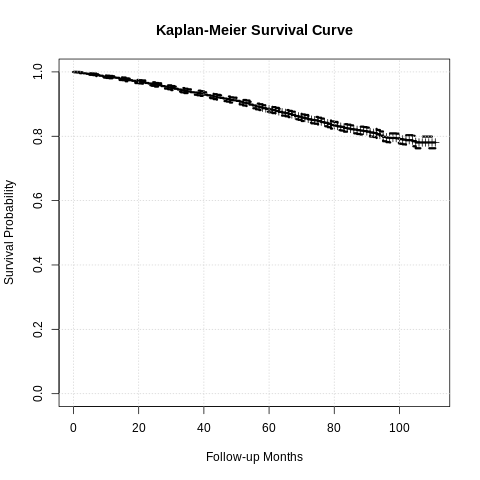

In [6]:
%%R

library(survival)

cat("Creating Kaplan-Meier curve...\n\n")

# -----------------------------------
# 1. Check required columns
# -----------------------------------

cat("Columns in dataset:\n")
print(names(post_5_covariates_fpca))

cat("\nDeath counts:\n")
print(table(post_5_covariates_fpca$death, useNA = "ifany"))

cat("\nFollow-up summary:\n")
print(summary(post_5_covariates_fpca$followup_months))

# -----------------------------------
# 2. Create survival object
# -----------------------------------

km_fit <- survfit(
  Surv(followup_months, death) ~ 1,
  data = post_5_covariates_fpca
)

cat("\nKM fit summary:\n")
print(summary(km_fit))

# -----------------------------------
# 3. Plot Kaplan-Meier curve
# -----------------------------------

plot(
  km_fit,
  xlab = "Follow-up Months",
  ylab = "Survival Probability",
  main = "Kaplan-Meier Survival Curve",
  lwd = 3,
  mark.time = TRUE
)

grid()

cat("\nFinished plotting Kaplan-Meier curve.\n")

Creating Kaplan-Meier curve...

Columns in dataset:
 [1] "SEQN"               "cycle"              "age"               
 [4] "bmi"                "sex"                "race_ethnicity"    
 [7] "education"          "marital_status"     "smoking_status"    
[10] "alcohol_use"        "hypertension"       "diabetes"          
[13] "heart_attack"       "stroke"             "cancer"            
[16] "self_rated_health"  "mortality_eligible" "death"             
[19] "followup_months"    "followup_years"     "FPCA_score_1"      
[22] "FPCA_score_2"       "FPCA_score_3"      

Death counts:

   0    1 
3824  801 

Follow-up summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   67.00   79.00   77.21   93.00  111.00 

KM fit summary:
Call: survfit(formula = Surv(followup_months, death) ~ 1, data = post_5_covariates_fpca)

 time n.risk n.event survival  std.err lower 95% CI upper 95% CI
    0   4625       1    1.000 0.000216        0.999        1.000
    1   4624       2    0.999 0.

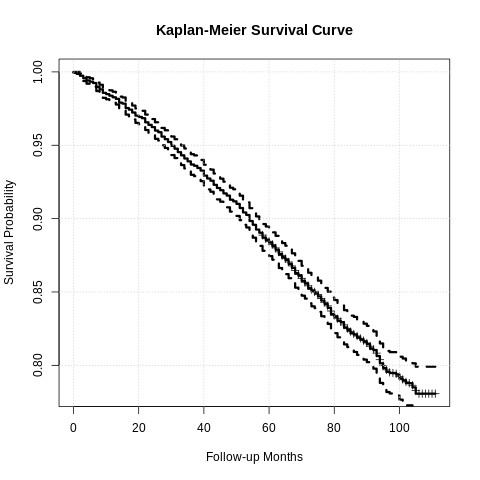

In [7]:
%%R

library(survival)

cat("Creating Kaplan-Meier curve...\n\n")

# -----------------------------------
# 1. Check required columns
# -----------------------------------

cat("Columns in dataset:\n")
print(names(post_5_covariates_fpca))

cat("\nDeath counts:\n")
print(table(post_5_covariates_fpca$death, useNA = "ifany"))

cat("\nFollow-up summary:\n")
print(summary(post_5_covariates_fpca$followup_months))

# -----------------------------------
# 2. Create survival object
# -----------------------------------

km_fit <- survfit(
  Surv(followup_months, death) ~ 1,
  data = post_5_covariates_fpca
)

cat("\nKM fit summary:\n")
print(summary(km_fit))

# -----------------------------------
# 3. Compute y-axis limits
# -----------------------------------

min_survival <- min(km_fit$surv, na.rm = TRUE)

cat("\nMinimum survival probability:\n")
print(min_survival)

# -----------------------------------
# 4. Plot Kaplan-Meier curve
# -----------------------------------

plot(
  km_fit,
  xlab = "Follow-up Months",
  ylab = "Survival Probability",
  main = "Kaplan-Meier Survival Curve",
  lwd = 3,
  mark.time = TRUE,
  ylim = c(min_survival, 1)
)

grid()

cat("\nFinished plotting Kaplan-Meier curve.\n")

Creating Kaplan-Meier curve...

Columns in dataset:
 [1] "SEQN"               "cycle"              "age"               
 [4] "bmi"                "sex"                "race_ethnicity"    
 [7] "education"          "marital_status"     "smoking_status"    
[10] "alcohol_use"        "hypertension"       "diabetes"          
[13] "heart_attack"       "stroke"             "cancer"            
[16] "self_rated_health"  "mortality_eligible" "death"             
[19] "followup_months"    "followup_years"     "FPCA_score_1"      
[22] "FPCA_score_2"       "FPCA_score_3"      

Death counts:

   0    1 
3824  801 

Follow-up summary (months):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   67.00   79.00   77.21   93.00  111.00 

Follow-up summary (years):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   5.583   6.583   6.434   7.750   9.250 

KM fit summary:
Call: survfit(formula = Surv(followup_months/12, death) ~ 1, data = post_5_covariates_fpca)

   time n.risk n.event s

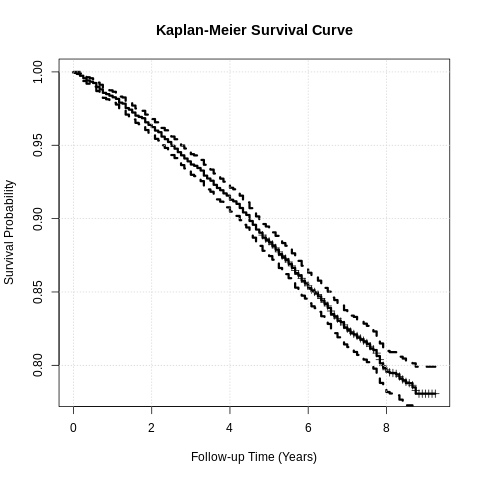

In [8]:
%%R

library(survival)

cat("Creating Kaplan-Meier curve...\n\n")

# -----------------------------------
# 1. Check required columns
# -----------------------------------

cat("Columns in dataset:\n")
print(names(post_5_covariates_fpca))

cat("\nDeath counts:\n")
print(table(post_5_covariates_fpca$death, useNA = "ifany"))

cat("\nFollow-up summary (months):\n")
print(summary(post_5_covariates_fpca$followup_months))

cat("\nFollow-up summary (years):\n")
print(summary(post_5_covariates_fpca$followup_months / 12))

# -----------------------------------
# 2. Create survival object in years
# -----------------------------------

km_fit <- survfit(
  Surv(followup_months / 12, death) ~ 1,
  data = post_5_covariates_fpca
)

cat("\nKM fit summary:\n")
print(summary(km_fit))

# -----------------------------------
# 3. Compute y-axis limits
# -----------------------------------

min_survival <- min(km_fit$surv, na.rm = TRUE)

cat("\nMinimum survival probability:\n")
print(min_survival)

# -----------------------------------
# 4. Plot Kaplan-Meier curve
# -----------------------------------

plot(
  km_fit,
  xlab = "Follow-up Time (Years)",
  ylab = "Survival Probability",
  main = "Kaplan-Meier Survival Curve",
  lwd = 3,
  mark.time = TRUE,
  ylim = c(min_survival, 1)
)

grid()

cat("\nFinished plotting Kaplan-Meier curve.\n")

# Comparing Distributions

In [9]:
%%R

library(survival)
library(dplyr)

cat("Debugging parametric survival model issue...\n\n")

# ----------------------------
# 1. Check dataset exists
# ----------------------------

cat("Does post_5_covariates_fpca exist?\n")
print(exists("post_5_covariates_fpca"))

if (!exists("post_5_covariates_fpca")) {
  stop("post_5_covariates_fpca does not exist.")
}

cat("\nDataset dimensions:\n")
print(dim(post_5_covariates_fpca))

cat("\nColumn names:\n")
print(names(post_5_covariates_fpca))

# ----------------------------
# 2. Check survival columns
# ----------------------------

cat("\nChecking survival columns...\n")

cat("followup_months exists:", "followup_months" %in% names(post_5_covariates_fpca), "\n")
cat("death exists:", "death" %in% names(post_5_covariates_fpca), "\n")

cat("\nClass of followup_months:\n")
print(class(post_5_covariates_fpca$followup_months))

cat("\nClass of death:\n")
print(class(post_5_covariates_fpca$death))

cat("\nSummary of followup_months:\n")
print(summary(post_5_covariates_fpca$followup_months))

cat("\nDeath counts:\n")
print(table(post_5_covariates_fpca$death, useNA = "ifany"))

# ----------------------------
# 3. Find bad survival times
# ----------------------------

cat("\nChecking invalid survival times...\n")

bad_time_rows <- post_5_covariates_fpca %>%
  filter(
    is.na(followup_months) |
      followup_months <= 0
  )

cat("Rows with missing or non-positive followup_months:\n")
print(nrow(bad_time_rows))

cat("\nFirst 20 bad time rows:\n")
print(as.data.frame(head(bad_time_rows, 20)))

cat("\nCounts of followup_months values <= 5 months:\n")
print(
  post_5_covariates_fpca %>%
    filter(!is.na(followup_months), followup_months <= 5) %>%
    count(followup_months, death) %>%
    arrange(followup_months, death)
)

# ----------------------------
# 4. Find bad event values
# ----------------------------

cat("\nChecking invalid death values...\n")

bad_death_rows <- post_5_covariates_fpca %>%
  filter(
    is.na(death) |
      !(death %in% c(0, 1))
  )

cat("Rows with missing or invalid death:\n")
print(nrow(bad_death_rows))

cat("\nFirst 20 bad death rows:\n")
print(as.data.frame(head(bad_death_rows, 20)))

# ----------------------------
# 5. Create cleaned survival dataset
# ----------------------------

cat("\nCreating parametric survival dataset with followup_months > 0 and death 0/1...\n")

parametric_data <- post_5_covariates_fpca %>%
  filter(
    !is.na(followup_months),
    followup_months > 0,
    !is.na(death),
    death %in% c(0, 1)
  )

cat("Original rows:\n")
print(nrow(post_5_covariates_fpca))

cat("Rows after cleaning:\n")
print(nrow(parametric_data))

cat("Rows removed:\n")
print(nrow(post_5_covariates_fpca) - nrow(parametric_data))

cat("\nFollow-up summary after cleaning:\n")
print(summary(parametric_data$followup_months))

cat("\nDeath counts after cleaning:\n")
print(table(parametric_data$death, useNA = "ifany"))

# ----------------------------
# 6. Try each model safely
# ----------------------------

cat("\nFitting models safely with tryCatch...\n\n")

fit_model_safely <- function(model_name, dist_name) {

  cat("Trying model:", model_name, "\n")

  fit <- tryCatch(
    {
      survreg(
        Surv(followup_months, death) ~ 1,
        data = parametric_data,
        dist = dist_name
      )
    },
    error = function(e) {
      cat("FAILED:", model_name, "\n")
      cat("Error message:", e$message, "\n\n")
      return(NULL)
    }
  )

  if (!is.null(fit)) {
    cat("SUCCESS:", model_name, "\n")
    cat("AIC:", AIC(fit), "\n\n")
  }

  return(fit)
}

exp_fit <- fit_model_safely("Exponential", "exponential")
weib_fit <- fit_model_safely("Weibull", "weibull")
lnorm_fit <- fit_model_safely("Log-normal", "lognormal")
llogis_fit <- fit_model_safely("Log-logistic", "loglogistic")

# ----------------------------
# 7. AIC comparison for successful models
# ----------------------------

cat("\nBuilding AIC table for successful models...\n")

aic_rows <- data.frame(
  model = character(),
  AIC = numeric()
)

if (!is.null(exp_fit)) {
  aic_rows <- bind_rows(aic_rows, data.frame(model = "Exponential", AIC = AIC(exp_fit)))
}

if (!is.null(weib_fit)) {
  aic_rows <- bind_rows(aic_rows, data.frame(model = "Weibull", AIC = AIC(weib_fit)))
}

if (!is.null(lnorm_fit)) {
  aic_rows <- bind_rows(aic_rows, data.frame(model = "Log-normal", AIC = AIC(lnorm_fit)))
}

if (!is.null(llogis_fit)) {
  aic_rows <- bind_rows(aic_rows, data.frame(model = "Log-logistic", AIC = AIC(llogis_fit)))
}

cat("\nAIC comparison:\n")
print(as.data.frame(aic_rows %>% arrange(AIC)))

# ----------------------------
# 8. Weibull interpretation
# ----------------------------

if (!is.null(weib_fit)) {

  cat("\nWeibull survreg scale:\n")
  print(weib_fit$scale)

  weibull_shape <- 1 / weib_fit$scale

  cat("\nWeibull shape parameter:\n")
  print(weibull_shape)

  cat("\nInterpretation:\n")

  if (weibull_shape > 1) {
    cat("Hazard increases over time.\n")
  } else if (weibull_shape < 1) {
    cat("Hazard decreases over time.\n")
  } else {
    cat("Hazard is approximately constant over time.\n")
  }
}

Debugging parametric survival model issue...

Does post_5_covariates_fpca exist?
[1] TRUE

Dataset dimensions:
[1] 4625   23

Column names:
 [1] "SEQN"               "cycle"              "age"               
 [4] "bmi"                "sex"                "race_ethnicity"    
 [7] "education"          "marital_status"     "smoking_status"    
[10] "alcohol_use"        "hypertension"       "diabetes"          
[13] "heart_attack"       "stroke"             "cancer"            
[16] "self_rated_health"  "mortality_eligible" "death"             
[19] "followup_months"    "followup_years"     "FPCA_score_1"      
[22] "FPCA_score_2"       "FPCA_score_3"      

Checking survival columns...
followup_months exists: TRUE 
death exists: TRUE 

Class of followup_months:
[1] "integer"

Class of death:
[1] "integer"

Summary of followup_months:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   67.00   79.00   77.21   93.00  111.00 

Death counts:

   0    1 
3824  801 

Checking invalid su

# AFT Analysis

In [11]:
%%R

library(survival)
library(dplyr)

cat("Running multivariable Weibull AFT model...\n\n")

# -----------------------------------
# 1. Create analysis dataset
# -----------------------------------

aft_data <- post_5_covariates_fpca %>%
  filter(
    !is.na(followup_months),
    followup_months > 0,
    !is.na(death),
    death %in% c(0, 1)
  )

cat("Rows before complete-case filtering:\n")
print(nrow(aft_data))

# -----------------------------------
# 2. Select variables
# -----------------------------------

analysis_vars <- c(
  "followup_months",
  "death",
  "FPCA_score_1",
  "age",
  "bmi",
  "sex",
  "race_ethnicity",
  "education",
  "marital_status",
  "smoking_status",
  "alcohol_use",
  "hypertension",
  "diabetes",
  "heart_attack",
  "stroke",
  "cancer",
  "self_rated_health"
)

cat("\nVariables used in model:\n")
print(analysis_vars)

# -----------------------------------
# 3. Missingness check
# -----------------------------------

cat("\nMissingness by variable:\n")

missing_table <- data.frame(
  variable = analysis_vars,

  missing_n = sapply(
    aft_data[, analysis_vars],
    function(x) sum(is.na(x))
  ),

  missing_percent = round(
    100 * sapply(
      aft_data[, analysis_vars],
      function(x) sum(is.na(x))
    ) / nrow(aft_data),
    1
  )
)

print(as.data.frame(missing_table))

# -----------------------------------
# 4. Complete-case dataset
# -----------------------------------

aft_complete <- aft_data %>%
  select(all_of(analysis_vars)) %>%
  na.omit()

cat("\nRows after complete-case filtering:\n")
print(nrow(aft_complete))

cat("\nRows removed due to missingness:\n")
print(nrow(aft_data) - nrow(aft_complete))

# -----------------------------------
# 5. Convert categorical variables
# -----------------------------------

cat("\nConverting categorical variables to factors...\n")

categorical_vars <- c(
  "sex",
  "race_ethnicity",
  "education",
  "marital_status",
  "smoking_status",
  "alcohol_use",
  "hypertension",
  "diabetes",
  "heart_attack",
  "stroke",
  "cancer",
  "self_rated_health"
)

aft_complete[categorical_vars] <- lapply(
  aft_complete[categorical_vars],
  factor
)

cat("\nFactor levels:\n")

for (var in categorical_vars) {

  cat("\n", var, ":\n", sep = "")
  print(levels(aft_complete[[var]]))
}

# -----------------------------------
# 6. Fit Weibull AFT model
# -----------------------------------

cat("\nFitting Weibull AFT model...\n\n")

weibull_aft <- survreg(
  Surv(followup_months, death) ~
    FPCA_score_1 +
    age +
    bmi +
    sex +
    race_ethnicity +
    education +
    marital_status +
    smoking_status +
    alcohol_use +
    hypertension +
    diabetes +
    heart_attack +
    stroke +
    cancer +
    self_rated_health,

  data = aft_complete,
  dist = "weibull"
)

cat("Model fit complete.\n\n")

# -----------------------------------
# 7. Print model summary
# -----------------------------------

cat("Full Weibull AFT summary:\n\n")

print(summary(weibull_aft))

# -----------------------------------
# 8. Extract coefficients
# -----------------------------------

cat("\nExtracting coefficient table...\n")

coef_table <- data.frame(
  variable = rownames(summary(weibull_aft)$table),

  coefficient = summary(weibull_aft)$table[, "Value"],

  standard_error = summary(weibull_aft)$table[, "Std. Error"],

  z_value = summary(weibull_aft)$table[, "z"],

  p_value = summary(weibull_aft)$table[, "p"]
)

print(as.data.frame(coef_table))

# -----------------------------------
# 9. Calculate time ratios
# -----------------------------------

cat("\nCalculating time ratios and 95% CI...\n")

time_ratio_table <- coef_table %>%
  filter(variable != "Log(scale)") %>%
  mutate(
    time_ratio = exp(coefficient),

    lower_ci = exp(
      coefficient - 1.96 * standard_error
    ),

    upper_ci = exp(
      coefficient + 1.96 * standard_error
    )
  )

print(as.data.frame(time_ratio_table))

# -----------------------------------
# 10. Weibull interpretation
# -----------------------------------

cat("\nWeibull distribution parameters:\n")

cat("survreg scale:\n")
print(weibull_aft$scale)

weibull_shape <- 1 / weibull_aft$scale

cat("\nWeibull shape parameter:\n")
print(weibull_shape)

cat("\nInterpretation:\n")

if (weibull_shape > 1) {
  cat("Hazard increases over time.\n")
} else if (weibull_shape < 1) {
  cat("Hazard decreases over time.\n")
} else {
  cat("Hazard approximately constant over time.\n")
}

# -----------------------------------
# 11. Overall model diagnostics
# -----------------------------------

cat("\nModel diagnostics:\n")

cat("\nAIC:\n")
print(AIC(weibull_aft))

cat("\nLog-likelihood:\n")
print(logLik(weibull_aft))

cat("\nNumber of observations used:\n")
print(weibull_aft$n)

cat("\nEvent counts:\n")
print(table(aft_complete$death))

Running multivariable Weibull AFT model...

Rows before complete-case filtering:
[1] 4624

Variables used in model:
 [1] "followup_months"   "death"             "FPCA_score_1"     
 [4] "age"               "bmi"               "sex"              
 [7] "race_ethnicity"    "education"         "marital_status"   
[10] "smoking_status"    "alcohol_use"       "hypertension"     
[13] "diabetes"          "heart_attack"      "stroke"           
[16] "cancer"            "self_rated_health"

Missingness by variable:
                           variable missing_n missing_percent
followup_months     followup_months         0             0.0
death                         death         0             0.0
FPCA_score_1           FPCA_score_1         0             0.0
age                             age         0             0.0
bmi                             bmi        66             1.4
sex                             sex         0             0.0
race_ethnicity       race_ethnicity         0         

# AFT Analysis with Splines

In [26]:
%%R

library(survival)
library(dplyr)
library(splines)

cat("Running multivariable Weibull AFT model with 2 df cubic spline for FPCA score...\n\n")

# Same setup code above stays unchanged

weibull_aft_spline2 <- survreg(
  Surv(followup_months, death) ~
    ns(FPCA_score_1, df = 2) +
    age +
    bmi +
    sex +
    race_ethnicity +
    education +
    marital_status +
    smoking_status +
    alcohol_use +
    hypertension +
    diabetes +
    heart_attack +
    stroke +
    cancer +
    self_rated_health,
  data = aft_complete,
  dist = "weibull"
)

cat("Model fit complete.\n\n")

cat("Full Weibull AFT spline model summary:\n\n")
print(summary(weibull_aft_spline2))

coef_table <- data.frame(
  variable = rownames(summary(weibull_aft_spline2)$table),
  coefficient = summary(weibull_aft_spline2)$table[, "Value"],
  standard_error = summary(weibull_aft_spline2)$table[, "Std. Error"],
  z_value = summary(weibull_aft_spline2)$table[, "z"],
  p_value = summary(weibull_aft_spline2)$table[, "p"]
)

print(as.data.frame(coef_table))

time_ratio_table <- coef_table %>%
  filter(variable != "Log(scale)") %>%
  mutate(
    time_ratio = exp(coefficient),
    lower_ci = exp(coefficient - 1.96 * standard_error),
    upper_ci = exp(coefficient + 1.96 * standard_error)
  )

print(as.data.frame(time_ratio_table))

cat("\nWeibull distribution parameters:\n")

cat("survreg scale:\n")
print(weibull_aft_spline2$scale)

weibull_shape <- 1 / weibull_aft_spline2$scale

cat("\nWeibull shape parameter:\n")
print(weibull_shape)

cat("\nModel diagnostics:\n")

cat("\nAIC:\n")
print(AIC(weibull_aft_spline2))

cat("\nLog-likelihood:\n")
print(logLik(weibull_aft_spline2))

cat("\nNumber of observations used:\n")
print(weibull_aft_spline2$n)

cat("\nEvent counts:\n")
print(table(aft_complete$death))

Running multivariable Weibull AFT model with 2 df cubic spline for FPCA score...

Model fit complete.

Full Weibull AFT spline model summary:


Call:
survreg(formula = Surv(followup_months, death) ~ ns(FPCA_score_1, 
    df = 2) + age + bmi + sex + race_ethnicity + education + 
    marital_status + smoking_status + alcohol_use + hypertension + 
    diabetes + heart_attack + stroke + cancer + self_rated_health, 
    data = aft_complete, dist = "weibull")
                                                     Value Std. Error      z
(Intercept)                                        7.89279    0.39492  19.99
ns(FPCA_score_1, df = 2)1                          1.93089    0.25028   7.71
ns(FPCA_score_1, df = 2)2                         -0.56588    0.47766  -1.18
age                                               -0.04879    0.00416 -11.74
bmi                                                0.02025    0.00453   4.47
sexMale                                           -0.28990    0.05883  -4.93
rac

In [28]:
%%R

library(splines)

cat("Extracting spline metadata from model...\n\n")

# Build the same spline basis used in the model
fpca_ns <- ns(
  aft_complete$FPCA_score_1,
  df = 2
)

cat("Spline basis first rows:\n")
print(head(fpca_ns))

cat("\nSpline attributes:\n")
print(attributes(fpca_ns))

cat("\nInternal knots:\n")
print(attr(fpca_ns, "knots"))

cat("\nBoundary knots:\n")
print(attr(fpca_ns, "Boundary.knots"))

cat("\nIntercept included?\n")
print(attr(fpca_ns, "intercept"))

Extracting spline metadata from model...

Spline basis first rows:
             1           2
[1,] 0.1061614 -0.06033807
[2,] 0.1245767 -0.07062618
[3,] 0.2613721 -0.14302792
[4,] 0.5459565 -0.17549994
[5,] 0.4900828 -0.20930013
[6,] 0.5357992 -0.18722859

Spline attributes:
$dim
[1] 4280    2

$dimnames
$dimnames[[1]]
NULL

$dimnames[[2]]
[1] "1" "2"


$degree
[1] 3

$knots
[1] -141.4223

$Boundary.knots
[1] -4719.818 13452.028

$intercept
[1] FALSE

$class
[1] "ns"     "basis"  "matrix"


Internal knots:
[1] -141.4223

Boundary knots:
[1] -4719.818 13452.028

Intercept included?
[1] FALSE


In [30]:
%%R

library(splines)

fpca_lookup <- data.frame(
  FPCA_score_1 = seq(
    -4719.818,
    13452.028,
    by = 1
  )
)

basis <- ns(
  fpca_lookup$FPCA_score_1,
  knots = -141.4223,
  Boundary.knots = c(
    -4719.818,
    13452.028
  ),
  intercept = FALSE
)

fpca_lookup$spline_1 <- basis[, 1]
fpca_lookup$spline_2 <- basis[, 2]

write.csv(
  fpca_lookup,
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/fpca_spline_lookup.csv",
  row.names = FALSE
)

In [31]:
%%R

library(survival)
library(splines)
library(dplyr)

cat("Testing R prediction for example patient...\n\n")

example_patient <- data.frame(
  FPCA_score_1 = 500,
  age = 50,
  bmi = 27,
  sex = "Male",
  race_ethnicity = "Non-Hispanic White",
  education = "College graduate+",
  marital_status = "Never married",
  smoking_status = "Never",
  alcohol_use = "Yes",
  hypertension = "No",
  diabetes = "No",
  heart_attack = "No",
  stroke = "No",
  cancer = "No",
  self_rated_health = "Very good"
)

# Match factor levels from training data
categorical_vars <- c(
  "sex",
  "race_ethnicity",
  "education",
  "marital_status",
  "smoking_status",
  "alcohol_use",
  "hypertension",
  "diabetes",
  "heart_attack",
  "stroke",
  "cancer",
  "self_rated_health"
)

for (var in categorical_vars) {
  example_patient[[var]] <- factor(
    example_patient[[var]],
    levels = levels(aft_complete[[var]])
  )
}

# Predict median survival from Weibull AFT spline model
predicted_median_months <- predict(
  weibull_aft_spline2,
  newdata = example_patient,
  type = "quantile",
  p = 0.5
)

predicted_median_years <- predicted_median_months / 12

predicted_age_at_death <- example_patient$age + predicted_median_years

cat("Predicted median survival months:\n")
print(predicted_median_months)

cat("\nPredicted median survival years:\n")
print(predicted_median_years)

cat("\nPredicted median age at death:\n")
print(predicted_age_at_death)

# 10-year death probability
lp <- predict(
  weibull_aft_spline2,
  newdata = example_patient,
  type = "lp"
)

shape_param <- 1 / weibull_aft_spline2$scale
scale_param <- exp(lp)

survival_10yr <- 1 - pweibull(
  120,
  shape = shape_param,
  scale = scale_param
)

death_10yr <- 1 - survival_10yr

cat("\nPredicted probability of dying within 10 years:\n")
print(death_10yr)

cat("\nPredicted probability of surviving 10 years:\n")
print(survival_10yr)

Testing R prediction for example patient...

Predicted median survival months:
       1 
674.3924 

Predicted median survival years:
       1 
56.19937 

Predicted median age at death:
       1 
106.1994 

Predicted probability of dying within 10 years:
[1] 0.0479045

Predicted probability of surviving 10 years:
[1] 0.9520955


In [13]:
%%R

mode_level <- function(x) {
  names(sort(table(x), decreasing = TRUE))[1]
}

new_patient <- data.frame(
  FPCA_score_1 = 4000,
  age = 50,
  bmi = median(aft_complete$bmi, na.rm = TRUE),
  sex = mode_level(aft_complete$sex),
  race_ethnicity = mode_level(aft_complete$race_ethnicity),
  education = mode_level(aft_complete$education),
  marital_status = mode_level(aft_complete$marital_status),
  smoking_status = mode_level(aft_complete$smoking_status),
  alcohol_use = mode_level(aft_complete$alcohol_use),
  hypertension = mode_level(aft_complete$hypertension),
  diabetes = mode_level(aft_complete$diabetes),
  heart_attack = mode_level(aft_complete$heart_attack),
  stroke = mode_level(aft_complete$stroke),
  cancer = mode_level(aft_complete$cancer),
  self_rated_health = mode_level(aft_complete$self_rated_health)
)

predicted_months <- predict(
  weibull_aft_spline3,
  newdata = new_patient,
  type = "response"
)

predicted_years <- predicted_months / 12

cat("Predicted survival time in months:\n")
print(predicted_months)

cat("\nPredicted survival time in years:\n")
print(predicted_years)

cat("\nEstimated age at death:\n")
print(50 + predicted_years)

Predicted survival time in months:
       1 
1456.567 

Predicted survival time in years:
       1 
121.3806 

Estimated age at death:
       1 
171.3806 
